In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from sensorium.utility.scores import get_correlations, get_poisson_loss
from nnfabrik.utility.nn_helpers import set_random_seed

In [2]:
seed = 42
set_random_seed(seed)

starting_epcoch = 1
multiplier = 100000.0
exponent=2.0
clusters=5
alpha=2.1
pretrain_epoch = 30
lr_model=0.002
#model_checkpoints/sensorium_model_dec_KL_EM_diagcov_exp_2_cluster_2_mult_4000000000.0_reg_adlognorm_se1.pth
path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}'
#path_ending = 'without_KL_sedd_10'

In [3]:
seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 1
torch.cuda.set_device(f"cuda:{cuda_number}")

# loading the SENSORIUM+ dataset
pre = "r/datasets/sensorium_2022_pictures/real_dataset/"
filenames = [f"{pre}{i}/" for i in os.listdir(pre)]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
    "seed": seed,
}

dataloaders = get_data(dataset_fn, dataset_config)
model_fn = 'sensorium.models.stacked_core_full_gauss_readout'
model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 10,
  'hidden_kern': 7,
  'hidden_channels': 128,
  'depth_separable': True,
  'grid_mean_predictor': {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True
   },
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': True,
  'regularizer_type': 'adaptive_log_norm',
  #'feature_reg_weight': 10,
}
model = get_model(
    model_fn=model_fn,
    model_config=model_config,
    dataloaders=dataloaders,
    seed=seed,
)

In [ ]:
device = f"cuda:{cuda_number}"
exponents = np.array([1.0,1.2,1.4,1.6,1.7,1.8,1.9,2.5,3.0])
cluster_numbers = np.array([10])
#,5,7,9,11,13,15,17,19,20,22,24,25,26,27,28,29,30,40,50])
dec_starting_epochs = np.array([8,9,11,12,13,14,15])


exponent=2.0
pretrain_epoch=10
lr_model = 0.008
multiplier = 1e5
cluster=15
regularizer ='adlognorm'
dim = ''

clusters = range(5,65,5)

pretrain_epochs = np.array([10,20,30,40])
alpha = 2.1
validation_correlation_dict = {}
learning_rates = np.array([0.003, 0.004, 0.005, 0.006,0.007,0.008])
keys1 = np.array([1e1,1e2,1e3])
keys2 = clusters
seeds = [42,10,100]

#for alpha in alphas:
for k1 in keys1:
    validation_correlation_dict[k1] = {}
    for k2 in keys2:
        multiplier=k1
        cluster=k2
        
        validation_correlation_dict[k1][k2] = {}
        for seed in seeds:
            path_ending = "ENTER PATH"
            save_path = f'model_checkpoints/sensorium_model_dec_{path_ending}.pth'
            if not os.path.exists(save_path):
                print(f"Warning: Model file not found for {save_path}. Inserting None.")
                validation_correlation_dict[k1][k2][seed] = np.nan
                continue  # Skip this iteration
            model.load_state_dict(torch.load(save_path),strict=False)
            validation_correlation = get_correlations(
                model,
                dataloaders,
                tier = 'test',
                device=device,
                as_dict=False,
                per_neuron=False,
            )
            validation_correlation_dict[k1][k2][seed] = validation_correlation


In [14]:
import pickle
import os


relative_path = 'validation_correlations/test_corr_smaller_mult_vs_cluster.pkl'

# Ensure the directory exists
os.makedirs(os.path.dirname(relative_path), exist_ok=True)

# Save with pickle
with open(relative_path, 'wb') as f:
    pickle.dump(validation_correlation_dict, f)

In [9]:
validation_correlation_woKL = []
device = f"cuda:{cuda_number}"
seeds = [10, 100, 42]
for seed in seeds:
    save_path = f'model_checkpoints/sensorium_model_dec_without_KL_seed_{seed}.pth'
    model.load_state_dict(torch.load(save_path), strict=False)
    validation_correlation_woKL.append(get_correlations(
        model,
        dataloaders,
        tier="test",
        device=device,
        as_dict=False,
        per_neuron=False,
    ))

In [ ]:
def plotting_validation_corr_errorbar(keys1,keys2, label1, label2, validation_correlation_dict=validation_correlation_dict):

    colors = [
       "orange","red","purple", "green", "blue", 
        "cyan", "magenta", "yellow", "brown", "pink", 'black'
    ]
    colors = [
          "blue", "magenta",  "cyan", "orange","red","purple","green"]  
    mean_woKL = np.mean(validation_correlation_woKL)
    std_woKL = np.std(validation_correlation_woKL)
    
    plt.figure(figsize=(10, 6), dpi=300)  # Set figure size
    fontsize=24
    for idx, k1 in enumerate(validation_correlation_dict.keys()):
        means = []
        std_devs = []
        color =colors[idx % len(colors)]
        for k2 in keys2:
            seeds = validation_correlation_dict[k1].get(k2, {})  # Get data for all seeds
            print(seeds)
            values = list(seeds.values())  # Extract correlation values

            if values:  # If there are valid data points
                mean_val = np.mean(values)  # Compute mean
                std_val = np.std(values)  # Compute standard deviation

                means.append(mean_val)
                std_devs.append(std_val)
            else:
                means.append(np.nan)  # Handle missing values
                std_devs.append(0)
        print(k1)
        exponent = int(np.log10(k1))  # Extracts exponent from scientific notation
        plt.errorbar(range(len(keys2)), means, yerr=std_devs,color =color, label=fr"$\beta$: $10^{{{exponent}}}$", capsize=3, marker='o')
    x_range = range(len(keys2))
    plt.plot([x_range[0], x_range[-1]], [mean_woKL, mean_woKL], color="#1f77b4", linestyle="--", label="Baseline")
    plt.fill_between(range(len(keys2)), mean_woKL - std_woKL, mean_woKL + std_woKL, color="#1f77b4", alpha=0.2)

    plt.xlabel(f"{label2}", fontsize=fontsize)
    plt.ylabel("Test Correlation", fontsize=fontsize)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Only horizontal grid lines
    plt.xticks(range(len(keys2)), [str(k) for k in keys2], fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.show()


def plot_validation_corr(keys1, keys2, validation_correlation_dict, label1, label2):
    """
    Plots validation correlation for a single seed (42) without error bars, using colorblind-friendly colors.

    Parameters:
    - keys1: List or array of primary keys (x-axis categories).
    - keys2: List or array of secondary keys (x-axis values).
    - validation_correlation_dict: Dictionary containing correlation values.
    - label1: Label for the legend.
    - label2: Label for the x-axis.
    """
    colors = [
        "orange","red","purple","green",  "blue", 
        "cyan", "magenta", "yellow", "brown", "pink", 'black'
    ]
    
    
    mean_woKL = np.mean(validation_correlation_woKL)
    std_woKL = np.std(validation_correlation_woKL)

    plt.figure(figsize=(10, 6), dpi=300)  # Set figure size

    for idx, k1 in enumerate(keys1):
        y_values = [validation_correlation_dict[k1][k2][42] for k2 in keys2]
        exponent = int(np.log10(k1))
        #color = color_palette(idx % 10)  # Cycle through colors safely
        color = color=colors[idx % len(colors)]
        if label1 == 'Mult':
            plt.plot(keys2, y_values, marker='o', label=fr"$\beta: 10^{{{exponent}}}$", color=colors[idx % len(colors)])
        else:
            plt.plot(keys2, y_values, marker='o', label=f'{label1} = {k1}', color=color)

    fontsize = 24
    plt.hlines(y=mean_woKL, xmin=min(keys2), xmax=max(keys2),color="#1f77b4",  linestyle="--", label="Baseline")
    plt.xlabel(f"{label2}", fontsize=fontsize)
    plt.ylabel("Validation Correlation", fontsize=fontsize)
    plt.legend(frameon=False, fontsize=fontsize, loc='lower left', bbox_to_anchor=(0.01, -0.05))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(keys2, [str(k) for k in keys2], fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    for spine in ['top', 'left', 'right', 'bottom']:
        plt.gca().spines[spine].set_visible(False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.show()


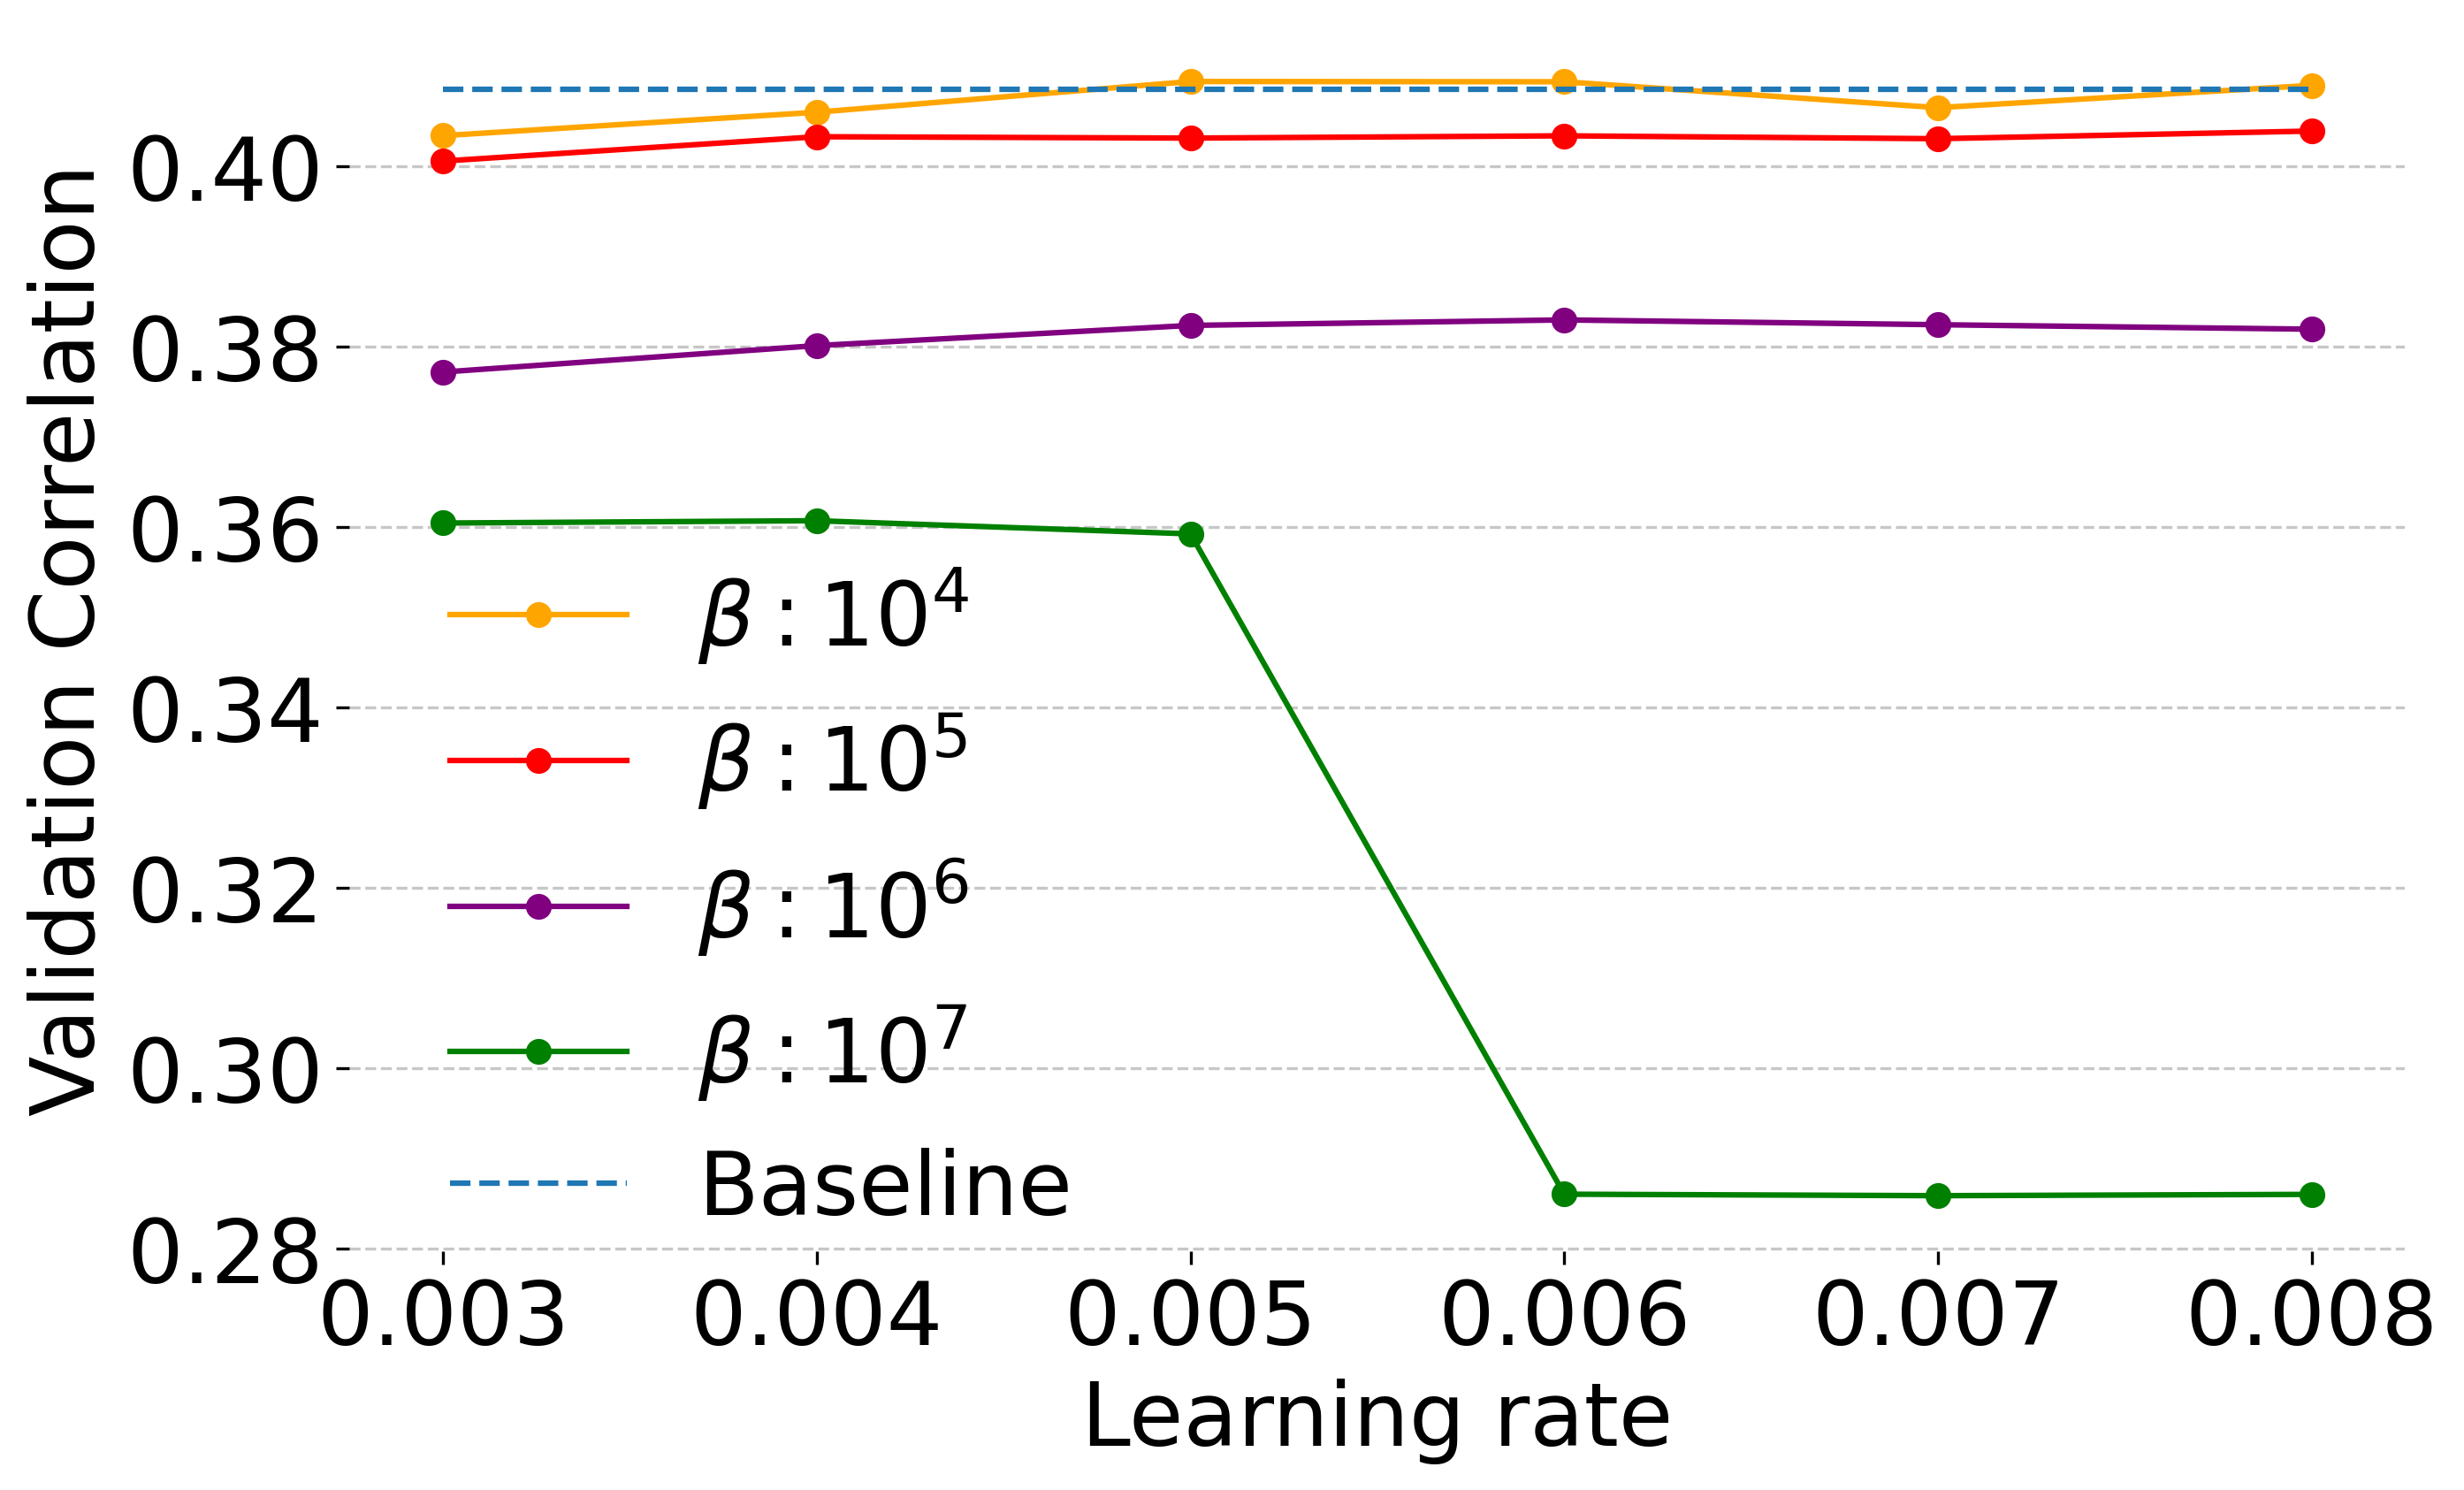

In [ ]:
keys1 = np.array([1e4,1e5,1e6,1e7])
#keys1 = [10,20,30,40]
keys1 = np.array([1e6,1e])
keys2 = [0.003, 0.004, 0.005, 0.006,0.007,0.008]
plot_validation_corr(keys1,keys2,validation_correlation_dict, 'Mult', 'Learning rate')